In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import scipy.stats as stats
import seaborn as sns
from scipy.stats import pearsonr

In [7]:
PATH = "/Users/wujiaqi/Desktop/427/academic_meals_elementary_district.csv"
df = pd.read_csv(PATH)
print("Shape:", df.shape)

Shape: (54, 263)


In [39]:
# 1) Basic structure 
#data types overview
dtype_table = df.dtypes.value_counts()
print("\nDtype counts:\n", dtype_table)


Dtype counts:
 float64    262
object       1
Name: count, dtype: int64


In [74]:
# 2) Pick key variables (edit if wanted)
KEY_VARS = [
    # Nutrition
    "HEI 2015 Total Score",
    "HEI 2015 Sodium (0-10)",
    "HEI 2015 Added Sugars (0-10)",
    "HEI 2015 Saturated Fats (0-10)",

    # Academic
    "ELA_Proficiency",
    "Math_Proficiency",
    "Science_Proficiency",

    # Socio
    "student_low_income_percent",
    "student_disabilities_percent",
]

SES = "student_low_income_percent"
HEI = "HEI 2015 Total Score"

KEY_VARS = [c for c in KEY_VARS if c in df.columns]

In [45]:
# 3) Summary statistics table
def summary_stats(s: pd.Series) -> dict:
    x = pd.to_numeric(s, errors="coerce")
    return {
        "N": x.notna().sum(),
        "Mean": x.mean(),
        "SD": x.std(ddof=1),
        "Median": x.median(),
        "Q1": x.quantile(0.25),
        "Q3": x.quantile(0.75),
        "Min": x.min(),
        "Max": x.max(),
    }

summary_table = pd.DataFrame({c: summary_stats(df[c]) for c in KEY_VARS}).T
summary_table = summary_table.round(3)
print("\nSummary table:\n", summary_table)


Summary table:
                                    N    Mean      SD  Median      Q1      Q3  \
HEI 2015 Total Score            54.0  57.218   8.354  58.952  52.105  62.814   
HEI 2015 Sodium (0-10)          54.0   4.541   1.843   4.463   3.568   6.048   
HEI 2015 Added Sugars (0-10)    54.0   8.197   1.706   8.650   7.741   9.473   
HEI 2015 Saturated Fats (0-10)  54.0   6.394   1.678   6.495   5.163   7.465   
ELA_Proficiency                 54.0  52.322  19.880  55.600  33.885  69.425   
Math_Proficiency                54.0  43.197  20.106  44.600  25.501  60.900   
Science_Proficiency             54.0  45.359  18.275  49.040  30.492  58.467   
student_low_income_percent      54.0  42.743  29.674  25.700  18.675  72.800   
student_disabilities_percent    53.0  18.098   3.807  17.700  15.500  20.700   

                                   Min     Max  
HEI 2015 Total Score            38.462  75.578  
HEI 2015 Sodium (0-10)           0.634   8.150  
HEI 2015 Added Sugars (0-10)     3.

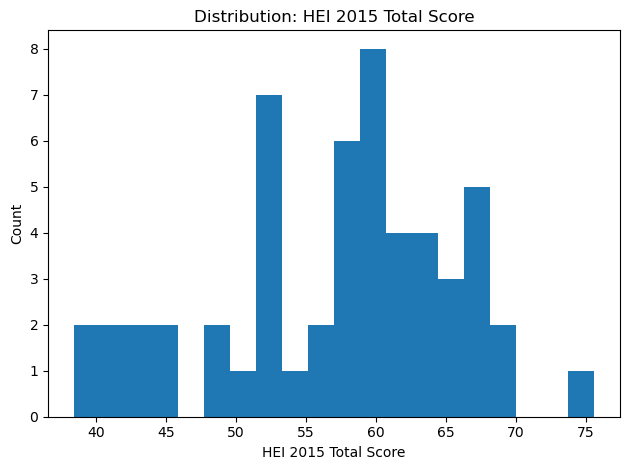

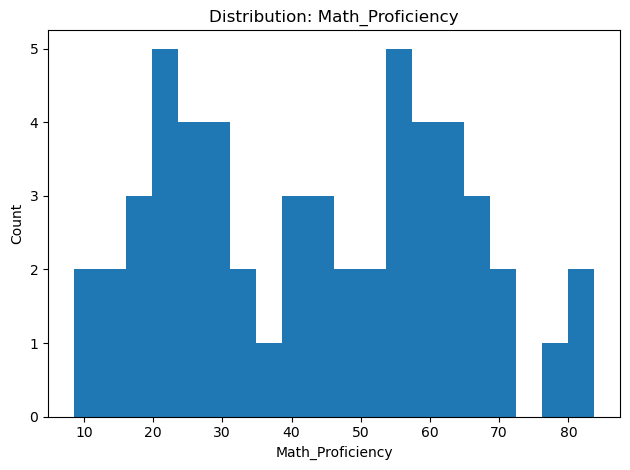

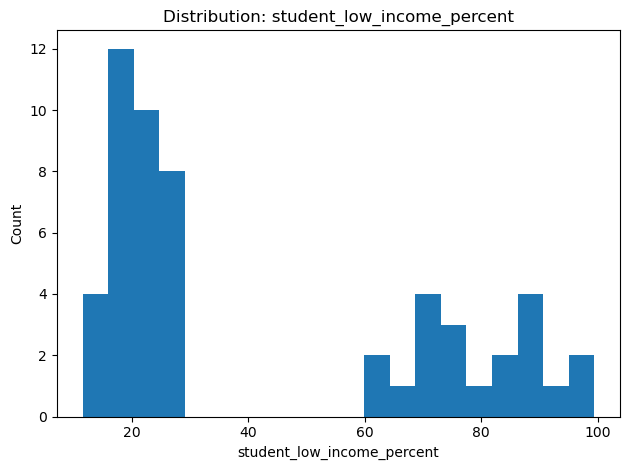

In [47]:
# 4) Univariate plots (histograms)
PLOT_VARS = [
    "HEI 2015 Total Score",
    "Math_Proficiency",
    "student_low_income_percent",
]
PLOT_VARS = [c for c in PLOT_VARS if c in df.columns]

for col in PLOT_VARS:
    x = pd.to_numeric(df[col], errors="coerce").dropna()
    plt.figure()
    plt.hist(x, bins=20)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(f"fig_hist_{re.sub(r'[^A-Za-z0-9]+','_',col)}.png", dpi=200)
    plt.show()

SES quartile counts:
ses_q
Q1 (lowest)     14
Q4 (highest)    14
Q2              13
Q3              13
Name: count, dtype: int64

Variable: HEI 2015 Total Score

Mean by SES quartile:
ses_q
Q1 (lowest)     57.244018
Q2              50.954508
Q3              61.159179
Q4 (highest)    59.346782
Name: HEI 2015 Total Score, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    60.125166
1    54.443364
2    57.274793
3    50.946356
4    47.760987
5    58.370620
6    62.486008
7    67.288963
8    58.814187
9    54.773231
Name: HEI 2015 Total Score, dtype: float64

Monotonic trend test (Kendall tau): tau=0.092, p=0.3247
ANOVA across quartiles: F=4.420, p=0.007818
Effect size (eta^2): 0.210


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


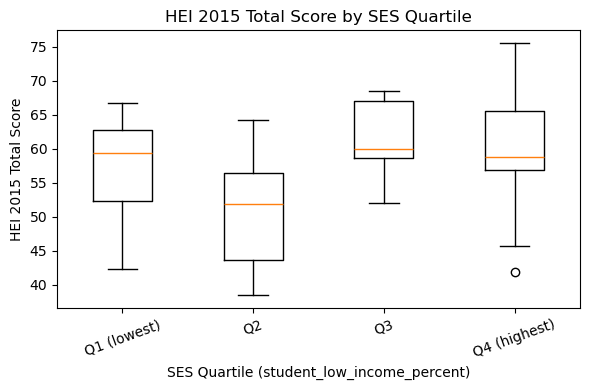


Variable: HEI 2015 Sodium (0-10)

Mean by SES quartile:
ses_q
Q1 (lowest)     4.073778
Q2              3.653963
Q3              5.772912
Q4 (highest)    4.688868
Name: HEI 2015 Sodium (0-10), dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    4.704318
1    2.646341
2    5.141662
3    3.531951
4    3.235358
5    6.102118
6    5.656217
7    5.838845
8    4.968449
9    3.701274
Name: HEI 2015 Sodium (0-10), dtype: float64

Monotonic trend test (Kendall tau): tau=0.117, p=0.2101
ANOVA across quartiles: F=3.785, p=0.01594
Effect size (eta^2): 0.185


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


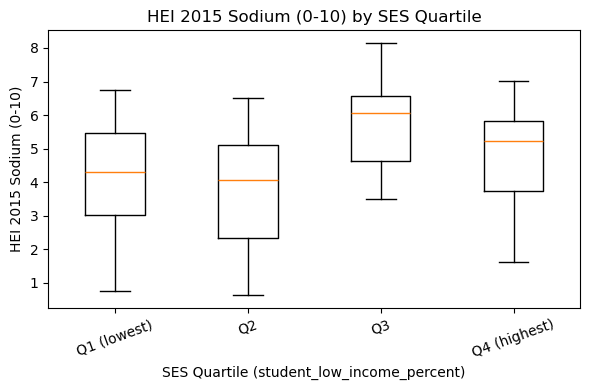


Variable: HEI 2015 Added Sugars (0-10)

Mean by SES quartile:
ses_q
Q1 (lowest)     8.724818
Q2              8.186404
Q3              8.096202
Q4 (highest)    7.772698
Name: HEI 2015 Added Sugars (0-10), dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    9.003625
1    9.139653
2    7.066456
3    8.679088
4    8.288777
5    9.212080
6    7.514175
7    5.725410
8    8.209172
9    8.875007
Name: HEI 2015 Added Sugars (0-10), dtype: float64

Monotonic trend test (Kendall tau): tau=-0.096, p=0.3032
ANOVA across quartiles: F=0.739, p=0.5335
Effect size (eta^2): 0.042


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


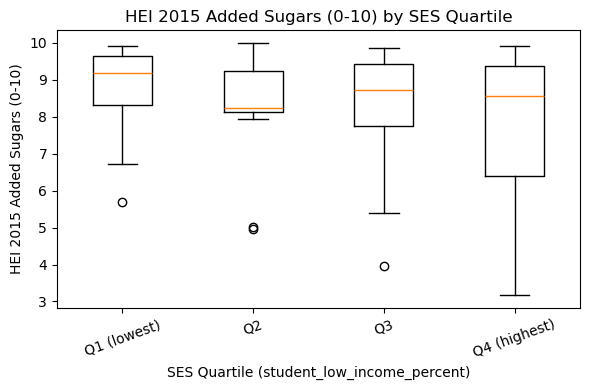


Variable: HEI 2015 Saturated Fats (0-10)

Mean by SES quartile:
ses_q
Q1 (lowest)     6.015725
Q2              6.215343
Q3              6.496469
Q4 (highest)    6.841811
Name: HEI 2015 Saturated Fats (0-10), dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    5.941745
1    5.561528
2    7.506989
3    6.170921
4    5.400206
5    6.105221
6    6.619273
7    8.422681
8    6.526880
9    5.874983
Name: HEI 2015 Saturated Fats (0-10), dtype: float64

Monotonic trend test (Kendall tau): tau=0.078, p=0.4034
ANOVA across quartiles: F=0.621, p=0.6048
Effect size (eta^2): 0.036


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


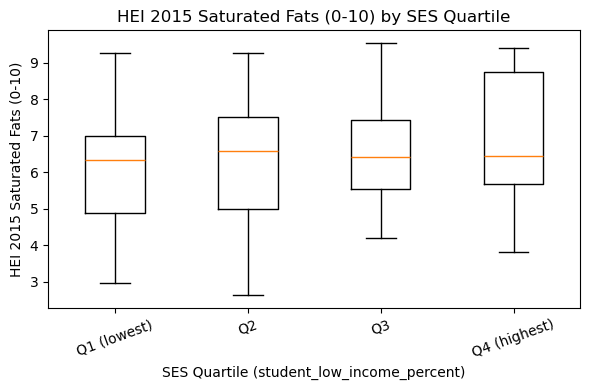


Variable: ELA_Proficiency

Mean by SES quartile:
ses_q
Q1 (lowest)     64.287143
Q2              68.786655
Q3              46.148456
Q4 (highest)    30.801676
Name: ELA_Proficiency, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    67.353333
1    63.220000
2    65.290303
3    65.637500
4    70.750000
5    62.532000
6    35.936935
7    30.645663
8    29.737692
9    33.492500
Name: ELA_Proficiency, dtype: float64

Monotonic trend test (Kendall tau): tau=-0.547, p=5.405e-09
ANOVA across quartiles: F=24.700, p=6.043e-10
Effect size (eta^2): 0.597


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


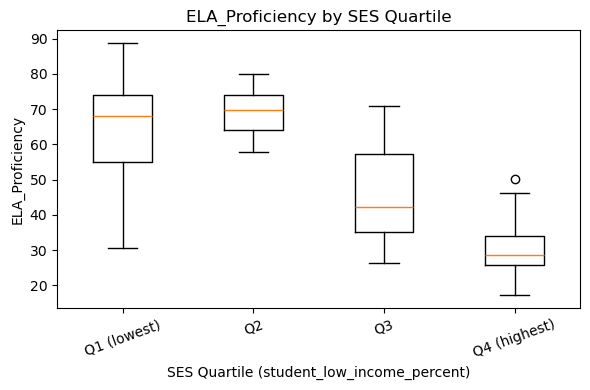


Variable: Math_Proficiency

Mean by SES quartile:
ses_q
Q1 (lowest)     57.894337
Q2              57.408974
Q3              36.991114
Q4 (highest)    21.066180
Name: Math_Proficiency, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    62.643333
1    53.425000
2    59.747143
3    55.550000
4    56.363333
5    49.128000
6    29.247390
7    25.255409
8    21.376923
9    20.254167
Name: Math_Proficiency, dtype: float64

Monotonic trend test (Kendall tau): tau=-0.575, p=8.644e-10
ANOVA across quartiles: F=25.755, p=3.246e-10
Effect size (eta^2): 0.607


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


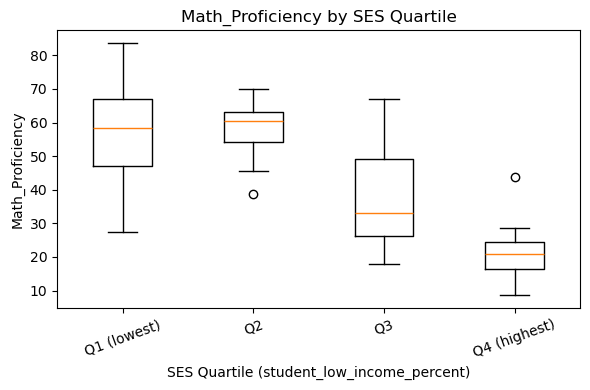


Variable: Science_Proficiency

Mean by SES quartile:
ses_q
Q1 (lowest)     55.698389
Q2              57.945504
Q3              42.316007
Q4 (highest)    26.157562
Name: Science_Proficiency, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    58.343289
1    54.115464
2    55.706865
3    58.445833
4    56.644523
5    58.029383
6    29.016857
7    35.433276
8    26.490707
9    23.740997
Name: Science_Proficiency, dtype: float64

Monotonic trend test (Kendall tau): tau=-0.459, p=9.873e-07
ANOVA across quartiles: F=16.620, p=1.273e-07
Effect size (eta^2): 0.499


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


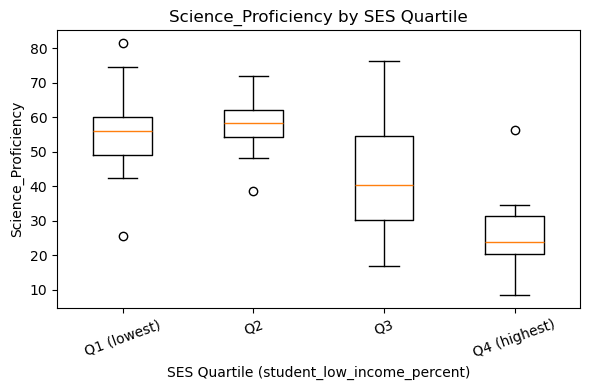


Variable: student_low_income_percent

Mean by SES quartile:
ses_q
Q1 (lowest)     16.514286
Q2              22.569231
Q3              45.715385
Q4 (highest)    84.942857
Name: student_low_income_percent, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    14.866667
1    17.480000
2    18.820000
3    22.233333
4    24.100000
5    26.380000
6    53.000000
7    73.020000
8    82.020000
9    93.066667
Name: student_low_income_percent, dtype: float64

Monotonic trend test (Kendall tau): tau=1.000, p=3.99e-52
ANOVA across quartiles: F=99.410, p=4.5e-21
Effect size (eta^2): 0.856


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


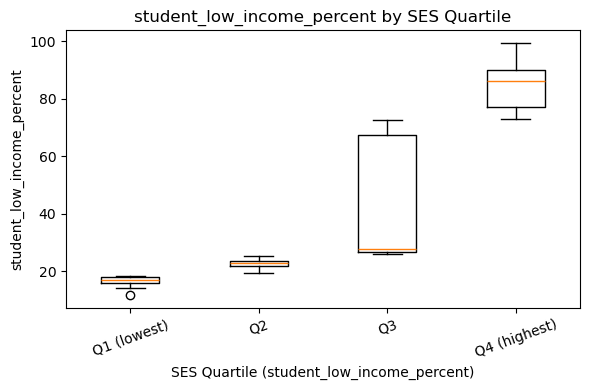


Variable: student_disabilities_percent

Mean by SES quartile:
ses_q
Q1 (lowest)     16.578571
Q2              18.169231
Q3              18.775000
Q4 (highest)    18.971429
Name: student_disabilities_percent, dtype: float64

Mean by SES decile (0=lowest SES, 9=highest SES):
ses_d
0    14.75
1    15.42
2    20.62
3    17.70
4    18.68
5    16.55
6    19.65
7    18.82
8    19.44
9    19.25
Name: student_disabilities_percent, dtype: float64

Monotonic trend test (Kendall tau): tau=0.226, p=0.01738
ANOVA across quartiles: F=1.125, p=0.3481
Effect size (eta^2): 0.064


/var/folders/sg/56qrdg_j5hd1k4pt1h7z6gs00000gn/T/ipykernel_30867/2898224455.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()


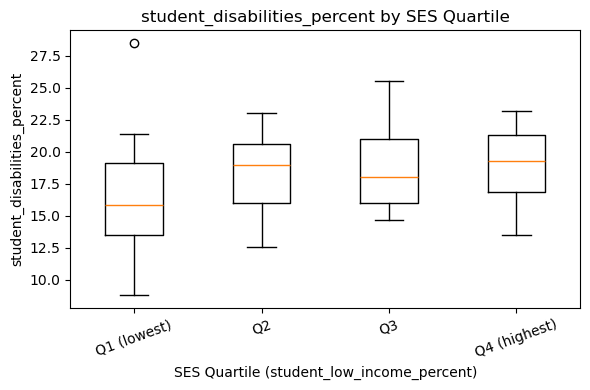

In [59]:
# 5) Grouped descriptive (income quartiles)
for col in set(KEY_VARS + [SES]):
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ses_q"] = pd.qcut(df[SES], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"], duplicates="drop") #Create SES groups (quartiles + deciles)
df["ses_d"] = pd.qcut(df[SES], 10, labels=False, duplicates="drop")

print("SES quartile counts:")
print(df["ses_q"].value_counts(dropna=False))

#tells how much of variation is explained by SES quartiles
def eta_squared(y, group):
    tmp = pd.DataFrame({"y": y, "g": group}).dropna()
    if tmp["g"].nunique() < 2:
        return np.nan
    
    overall_mean = tmp["y"].mean()
    ss_between = tmp.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - overall_mean) ** 2).sum()
    ss_total = ((tmp["y"] - overall_mean) ** 2).sum()
    
    if ss_total == 0:
        return np.nan
    return ss_between / ss_total

#main loop: do the same analysis for every key variable
for var in KEY_VARS:
    
    print("\n" + "="*70)
    print(f"Variable: {var}")
    print("="*70)
    
    #Mean by SES quartile
    quartile_means = df.groupby("ses_q", observed=True)[var].mean()
    print("\nMean by SES quartile:")
    print(quartile_means)
    
    #Mean by SES decile
    decile_means = df.groupby("ses_d")[var].mean()
    print("\nMean by SES decile (0=lowest SES, 9=highest SES):")
    print(decile_means)
    
    #Monotonic trend test
    tmp = df[[SES, var]].dropna()
    if len(tmp) >= 10:
        tau, p = stats.kendalltau(tmp[SES], tmp[var])
        print(f"\nMonotonic trend test (Kendall tau): tau={tau:.3f}, p={p:.4g}")
    else:
        print("\nKendall tau test skipped (too few data points).")
    
    #ANOVA across quartiles (are the quartile means different?)
    groups = [df.loc[df["ses_q"] == q, var].dropna() for q in df["ses_q"].dropna().unique()]
    if len(groups) >= 2 and all(len(g) > 1 for g in groups):
        f_stat, p_val = stats.f_oneway(*groups)
        print(f"ANOVA across quartiles: F={f_stat:.3f}, p={p_val:.4g}")
    else:
        print("ANOVA skipped (not enough data in groups).")
    
    #Effect size
    eta2 = eta_squared(df[var], df["ses_q"])
    if pd.notna(eta2):
        print(f"Effect size (eta^2): {eta2:.3f}")
    else:
        print("Effect size (eta^2): NA")
    
    #Boxplot for visual comparison
    plt.figure(figsize=(6,4))
    data = []
    labels = []
    for q in ["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"]:
        vals = df.loc[df["ses_q"] == q, var].dropna()
        if len(vals) > 0:
            data.append(vals)
            labels.append(q)
            
    plt.boxplot(data, tick_labels=labels, showfliers=True)
    plt.title(f"{var} by SES Quartile")
    plt.xlabel("SES Quartile (student_low_income_percent)")
    plt.ylabel(var)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

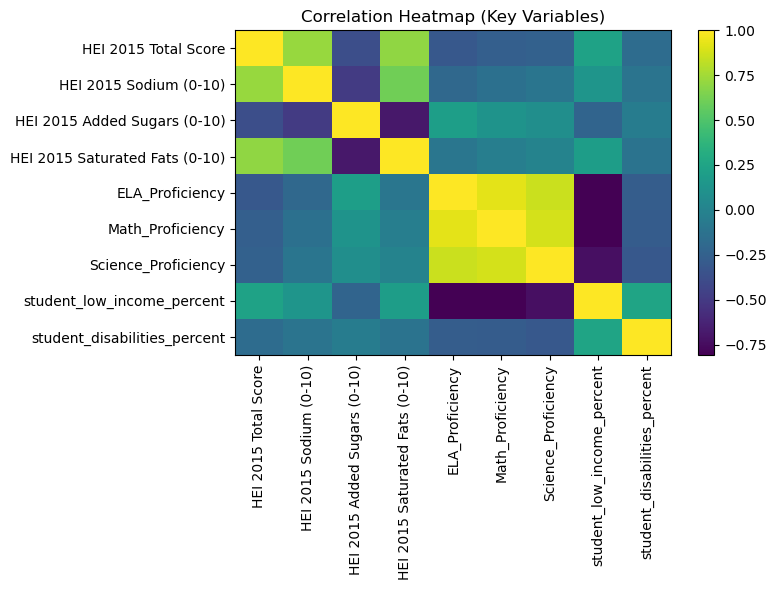

In [25]:
# 6) Correlation (key numeric vars)
num_df = df[KEY_VARS].apply(pd.to_numeric, errors="coerce")
corr = num_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap (Key Variables)")
plt.tight_layout()
plt.savefig("fig_corr_heatmap_keyvars.png", dpi=200)
plt.show()

## 6. Correlation Structure Among Key Variables

Figure 6 presents the correlation matrix for the key nutrition, academic, and socioeconomic variables.

Several clear patterns emerge from the heatmap.

### 1. Academic Proficiency Measures

ELA, Math, and Science proficiency rates are highly positively correlated with one another.  
This indicates that these measures capture closely related dimensions of district-level academic performance. Districts performing well in one subject tend to perform well in others.

### 2. Nutrition Quality Measures

The HEI 2015 Total Score is positively correlated with several of its component scores (e.g., Sodium, Saturated Fats).  
This is expected because the total score is constructed as a composite index of these components.  
The strong internal correlations confirm the internal consistency of the nutrition quality measure.

### 3. Socioeconomic Context

The percentage of low-income students (`student_low_income_percent`) exhibits a strong negative correlation with academic proficiency outcomes.  
Districts with higher levels of socioeconomic disadvantage tend to have lower proficiency rates across subjects.

### 4. Nutrition and Academic Outcomes

The correlation between overall nutrition quality (HEI Total Score) and academic proficiency appears relatively weak in the raw (unadjusted) correlation matrix.  
This suggests that any potential relationship between nutrition quality and academic performance may be mediated or confounded by socioeconomic factors.

---

Overall, the correlation structure indicates that socioeconomic context plays a central role in explaining variation in academic performance, while the direct association between nutrition quality and proficiency outcomes appears modest at the descriptive level.

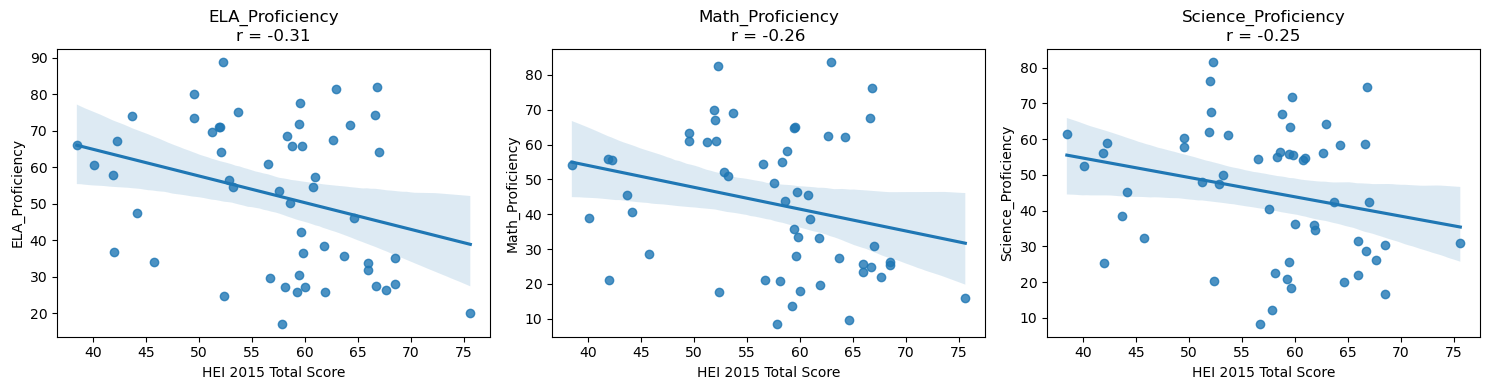

In [86]:
# 7) Scatter: HEI Total vs ELA\Math\Science proficiency (+ simple trend line)
fig, axes = plt.subplots(1,3, figsize=(15,4))

outcomes = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

for ax, outcome in zip(axes, outcomes):
    tmp = df[[HEI, outcome]].dropna()
    r, _ = pearsonr(tmp[HEI], tmp[outcome])
    
    sns.regplot(x=HEI, y=outcome, data=tmp, ax=ax, ci=95)
    ax.set_title(f"{outcome}\nr = {r:.2f}")

plt.tight_layout()
plt.show()

## 7. Bivariate Relationship Between Nutrition Quality and Academic Outcomes

Figure 7 illustrates the relationship between the HEI 2015 Total Score and academic proficiency outcomes (ELA, Math, and Science), along with fitted linear trend lines.

Across all three subjects, the correlations are negative and modest in magnitude:

- ELA Proficiency: r = -0.31  
- Math Proficiency: r = -0.26  
- Science Proficiency: r = -0.25  

These results indicate a weak-to-moderate negative association between overall nutrition quality (HEI total score) and district-level academic proficiency in the raw, unadjusted data.

The negative slope observed in each scatterplot suggests that districts with higher HEI scores tend to exhibit slightly lower proficiency rates. However, the strength of these correlations remains relatively modest.

Importantly, these associations are descriptive and do not account for potential confounding factors such as socioeconomic context. Given the strong relationship previously observed between low-income percentage and academic performance, it is plausible that socioeconomic characteristics may mediate or confound the observed relationship between nutrition quality and proficiency outcomes.

Overall, at the descriptive level, the direct linear association between HEI total score and academic performance appears limited and warrants further investigation with controlled analysis.